In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

from RunSimulator import RunSimulator
from PathPlotter import PathPlotter
master = RunSimulator()

"""
hi indira & tristan & whoever else it concerns
youll have to run this jupyter notebook from beginning prob
tips for jupyter notebook:
1) keep track of what you ran. try NOT to run cells out of order.
2) this may seem easier than normal coding but its actually like not. be careful.
3) fyi ipynbs are 'modified' if code OR cell output changes
"""

"\nhi indira & tristan & whoever else it concerns\nyoull have to run this jupyter notebook from beginning prob\ntips for jupyter notebook:\n1) keep track of what you ran. try NOT to run cells out of order.\n2) this may seem easier than normal coding but its actually like not. be careful.\n3) fyi ipynbs are 'modified' if code OR cell output changes\n"

In [2]:
#baseline constants
baseline_trial_num = 10
error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim=20000
deltahead=2.4

#running trials!
random.seed(42) # NOTE: only set this when you want to RESET the module
master.baseline(baseline_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead)
baseline_final_drifts = master.all_final_drift
baseline_mean_errors = master.all_mean_error
baseline_rmses = master.all_rmse
baseline_errors_over_time = master.all_error_over_time


the mouse moved this far: 324.8378051033331
[[-72.11040188 316.73283626]]
[-105.07497661  297.65978971]
the mouse moved this far: 645.4915509755027
[[-93.12732954 638.73832113]]
[-118.49492611  669.06042011]
the mouse moved this far: 830.8038755403552
[[334.79828485 760.35859177]]
[220.17549793 561.55514194]
the mouse moved this far: 590.563512381621
[[249.7969485  535.13245713]]
[309.47086717 584.31428294]
the mouse moved this far: 305.990081648238
[[223.24507229 209.26434901]]
[217.33294212 201.21018158]
the mouse moved this far: 695.1659687110055
[[618.37083717 317.60546561]]
[575.19349101 236.63400544]
the mouse moved this far: 612.8661508425307
[[-214.45005275 -574.12201989]]
[-207.91063738 -492.9323962 ]
the mouse moved this far: 1032.6281339507282
[[343.57996188 973.79344464]]
[315.75572931 963.05157201]
the mouse moved this far: 372.04076090991634
[[187.47003748 321.35543068]]
[169.5254211  307.00623616]
the mouse moved this far: 423.6262484642674
[[379.17139363 188.91334691]]


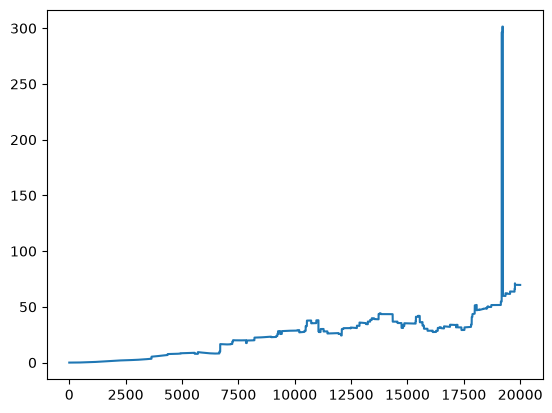

In [3]:
#plot error over time
x = np.arange(sim) # this only works now in this specific case bc error_freq=1
y = np.mean(baseline_errors_over_time, axis=0)

plt.plot(x,y)
plt.show()

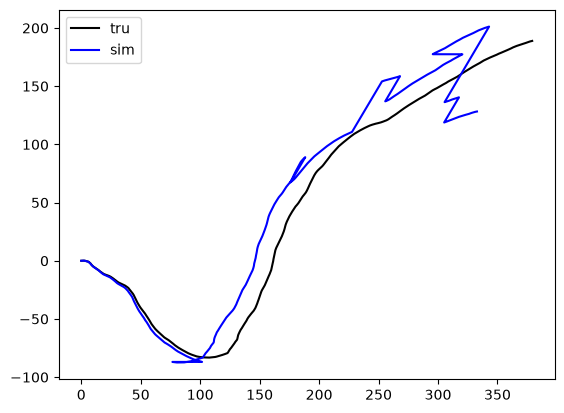

In [4]:
#plot true path vs sim path over time

pathplotter = PathPlotter()
path_array = np.zeros((2,sim,2))
path_array[0] = master.trimmed_og_pos
path_array[1] = master.trimmed_sim_pos
pathplotter.paths(path_array, colors=["black", "blue"],labels=["tru", "sim"])



In [5]:
#simulation time trial constants
simlen_trial_num = 3
simlen_iters = 10

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_list=(np.arange(simlen_iters)+1)*10000
deltahead=2.4

#running trials!
sim_trial_final_drifts = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_mean_errors = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_rmses = np.zeros((simlen_iters,simlen_trial_num))
sim_trial_errors_over_time = [] #NOT a numpy array. its a 3d one, iter x simlen trial_num x floor(simlen/errorfreq)

for i in range(simlen_iters):
    master.baseline(simlen_trial_num, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim_list[i], deltahead=deltahead)
    sim_trial_final_drifts[i] = master.all_final_drift
    sim_trial_mean_errors[i] = master.all_mean_error
    sim_trial_rmses[i] = master.all_rmse
    sim_trial_errors_over_time.append(master.all_error_over_time)

the mouse moved this far: 400.85624507863236
[[ 73.61503462 394.03877461]]
[ 77.12828149 438.68687229]
the mouse moved this far: 432.95029128523805
[[421.74583437 -97.8591126 ]]
[363.73309555 -75.03759932]
the mouse moved this far: 343.2740563099312
[[241.77797498 243.68112063]]
[240.24814011 283.18951346]
the mouse moved this far: 769.6306167126454
[[ 706.4463433  -305.39294396]]
[ 700.11479968 -331.03325437]
the mouse moved this far: 642.6573537232538
[[584.2974728  267.59098933]]
[559.89755377 258.06401849]
the mouse moved this far: 621.6513305864074
[[ 362.79877393 -504.80434473]]
[ 360.59461967 -449.05585798]
the mouse moved this far: 626.5619015143376
[[-596.8355601   190.70167967]]
[-637.47863422  188.57499288]
the mouse moved this far: 732.7751729286965
[[161.38906221 714.78180213]]
[180.28321204 698.77546623]
the mouse moved this far: 339.33102437224557
[[117.27033304 318.42300967]]
[  9.08483791 133.90970894]
the mouse moved this far: 561.4025225556919
[[556.85709864  71.2949

KeyboardInterrupt: 

In [ ]:
print(sim_trial_final_drifts.shape)
print(sim_trial_mean_errors.shape)
print(sim_trial_rmses.shape)
print(f"{len(sim_trial_errors_over_time)}, {len(sim_trial_errors_over_time[0])}, {len(sim_trial_errors_over_time[0][0])}")

(10, 3)
(10, 3)
(10, 3)
10, 3, 10000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{(i + 1) * 10000}" for i in range(10)]
x_pos = np.arange(len(x_labels))

avg_final_drifts = np.mean(sim_trial_final_drifts, axis=1)
avg_mean_errors = np.mean(sim_trial_mean_errors, axis=1)
avg_rmses = np.mean(sim_trial_rmses, axis=1)

sim_graphs = [
    ("Final Drift", avg_final_drifts),
    ("Mean Error", avg_mean_errors),
    ("RMSE", avg_rmses),
]

for title, data in sim_graphs:
    plt.figure(figsize=(10, 5))
    plt.bar(x_pos, data, color="pink", edgecolor="black")
    plt.xticks(x_pos, x_labels, rotation=45)
    plt.xlabel("Simulation Length")
    plt.ylabel("Error")
    plt.title(f"Average {title} vs Simulation Length")
    plt.tight_layout()
    plt.show()

In [ ]:
# module number trial . keep range the same from 25 cm to 22.6m
module_num_trial_num = 3
module_num_iters = range(5,14)
module_num_spacings = [np.power(2266./25., (1/i)) for i in module_num_iters]
module_num_len = len(module_num_iters)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim = 20000
deltahead=2.4

#running trials!
module_num_final_drifts = np.zeros((module_num_len,module_num_trial_num))
module_num_mean_errors = np.zeros((module_num_len,module_num_trial_num))
module_num_rmses = np.zeros((module_num_len,module_num_trial_num))
module_num_errors_over_time = [] #NOT a numpy array. its a 3d one, len x trial_num x floor(simlen/errorfreq)

for i in range(module_num_len):
    master.baseline(module_num_len, error_freq=error_freq,speed_noise_amplitude=speed_noise_amplitude,
                    headdir_noise_amplitude=headdir_noise_amplitude, ts=ts, sim=sim, deltahead=deltahead,
                    NUM_OF_MODS=module_num_iters[i], spacing_min=25,spacing = module_num_spacings[i])
    module_num_final_drifts[i] = master.all_final_drift
    module_num_mean_errors[i] = master.all_mean_error
    module_num_rmses[i] = master.all_rmse
    module_num_errors_over_time.append(master.all_error_over_time)

In [ ]:
"""tristan ... if you want can you make BAR charts of 
module_num_final_drifts, module_num_mean_errors, module_num_rmses
 (theres like 9 bars) 
x goes from 5 to 13
y is the error 
"""

In [ ]:
# module spacing trial..... do tmrw sophie
